# 01 — Exploratory Data Analysis

Sanity-check data loading, inspect metadata, visualize trajectories,
and verify that training windows are reasonable across all cells and conditions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())

from chromlearn.analysis.trajectory_viz import plot_cell_trajectories, plot_chromosome_cloud
from chromlearn.io.catalog import CONDITIONS, list_cells, load_condition
from chromlearn.io.loader import CellData, load_cell
from chromlearn.io.trajectory import compute_end_sep, pole_pole_distance, trim_trajectory

plt.rcParams["figure.dpi"] = 110

## Single-cell walkthrough

Load one rpe18_ctr cell and inspect its structure.

In [2]:
cells_ctr = list_cells("rpe18_ctr")
print(f"Found {len(cells_ctr)} rpe18_ctr cells:")
for cell_id in cells_ctr:
    print(f"  {cell_id}")

Found 13 rpe18_ctr cells:
  rpe18_ctr_006
  rpe18_ctr_032
  rpe18_ctr_034
  rpe18_ctr_035
  rpe18_ctr_043
  rpe18_ctr_049
  rpe18_ctr_500
  rpe18_ctr_501
  rpe18_ctr_502
  rpe18_ctr_505
  rpe18_ctr_506
  rpe18_ctr_507
  rpe18_ctr_509


In [3]:
DATA_DIR = ROOT / "data"
cell = load_cell(DATA_DIR / f"{cells_ctr[0]}.mat")
print(f"Cell ID: {cell.cell_id}")
print(f"Condition: {cell.condition}")
print(f"Centrioles shape: {cell.centrioles.shape}")
print(f"Chromosomes shape: {cell.chromosomes.shape}")
print(f"NEB frame: {cell.neb} (1-based)")
print(f"AO1: {cell.ao1}, AO2: {cell.ao2}")
print(f"Tracked chromosomes: {cell.tracked}")
print(f"NaN count in chromosomes: {np.isnan(cell.chromosomes).sum()}")

Cell ID: rpe18_ctr_006
Condition: rpe18_ctr
Centrioles shape: (216, 3, 2)
Chromosomes shape: (216, 3, 46)
NEB frame: 7 (1-based)
AO1: 216, AO2: 216
Tracked chromosomes: 46
NaN count in chromosomes: 0


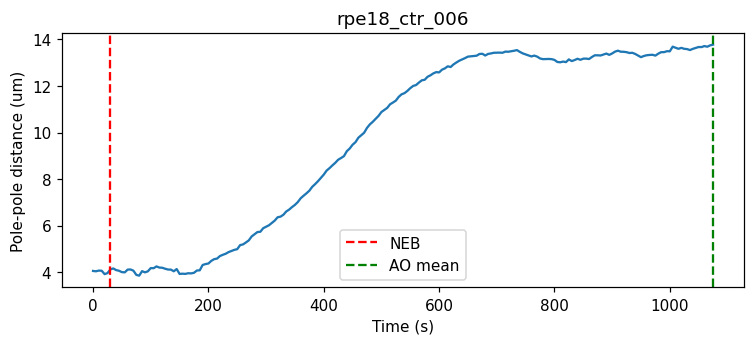

In [4]:
ppd = pole_pole_distance(cell)
time = np.arange(len(ppd)) * cell.dt
figure, axis = plt.subplots(figsize=(8, 3))
axis.plot(time, ppd)
axis.axvline((cell.neb - 1) * cell.dt, color="r", linestyle="--", label="NEB")
ao_mean = (cell.ao1 + cell.ao2) / 2.0
axis.axvline((ao_mean - 1) * cell.dt, color="g", linestyle="--", label="AO mean")
axis.set_xlabel("Time (s)")
axis.set_ylabel("Pole-pole distance (um)")
axis.set_title(cell.cell_id)
axis.legend()
plt.show()

Trimmed frames: 6-110 (105 timepoints)


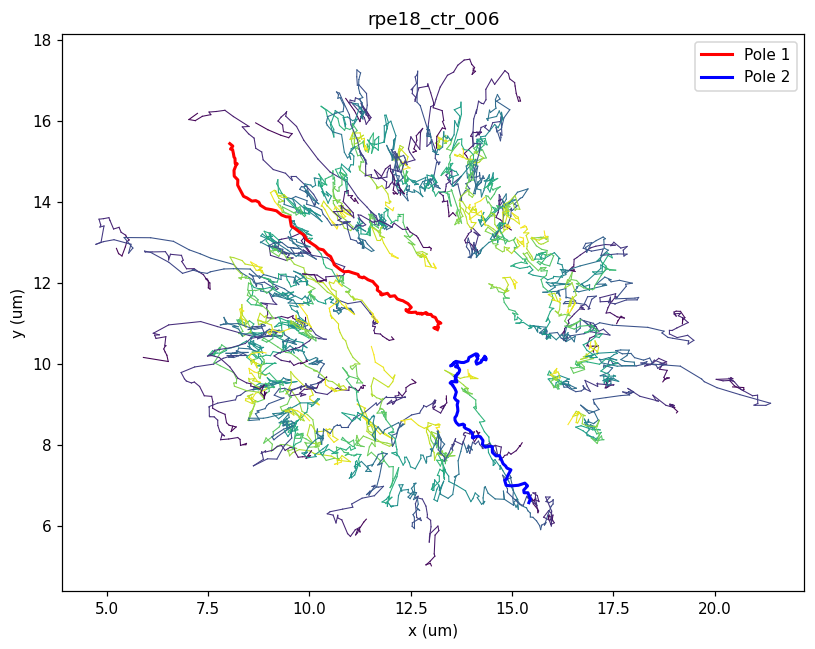

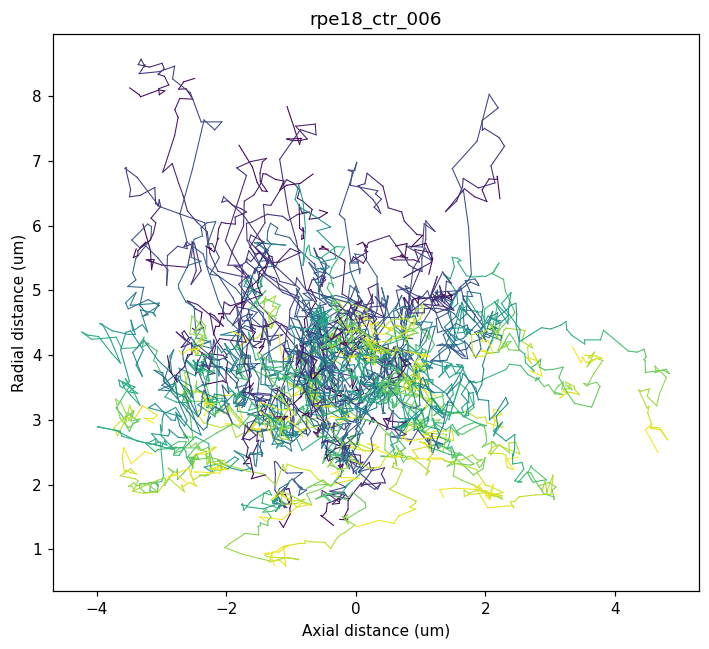

In [5]:
trimmed = trim_trajectory(cell, method="neb_ao_frac")
print(
    f"Trimmed frames: {trimmed.start_frame}-{trimmed.end_frame} "
    f"({trimmed.chromosomes.shape[0]} timepoints)"
)
plot_cell_trajectories(trimmed, frame="lab")
plt.show()
plot_cell_trajectories(trimmed, frame="spindle")
plt.show()

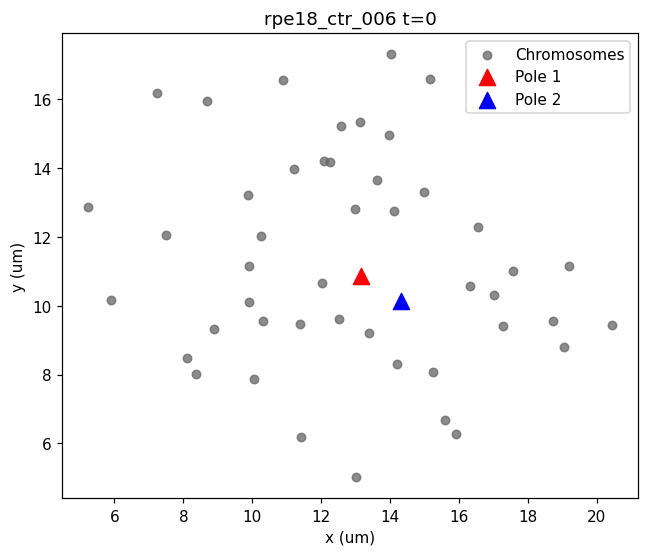

In [6]:
plot_chromosome_cloud(trimmed, timepoint=0)
plt.show()

## Per-cell summary — all conditions

For every cell across all conditions, report:
- tracked chromosome count and tracking gaps (NaN)
- training window length under both endpoint methods
- flag if any window is too short (< 100 frames)

In [7]:
MIN_FRAMES = 100

all_conditions = list(CONDITIONS.keys())
all_cells: list[CellData] = []
for cond in all_conditions:
    all_cells.extend(load_condition(cond))

print(f"{'cell_id':<28} {'tracked':>7} {'gaps':>5} "
      f"{'mid(NEB,AO)':>12} {'end_sep':>8} {'flag':>5}")
print("-" * 72)

# Store per-cell window info for the grid plot
window_info: dict[str, dict] = {}

for c in all_cells:
    # Tracking gaps: chromosomes with any NaN in their position timeseries
    # chromosomes shape is (T, 3, N)
    nan_per_chrom = np.any(np.isnan(c.chromosomes), axis=(0, 1))  # shape (N,)
    n_gaps = int(nan_per_chrom.sum())

    # Training window lengths for each endpoint method
    neb_frame = c.neb - 1
    ao_mean_frame = int(round((c.ao1 + c.ao2) / 2.0)) - 1
    midpoint_frame = (neb_frame + ao_mean_frame) // 2
    end_sep_frame = compute_end_sep(c)

    mid_len = midpoint_frame - neb_frame + 1
    sep_len = end_sep_frame - neb_frame + 1

    short = mid_len < MIN_FRAMES or sep_len < MIN_FRAMES
    flag = " ***" if short else ""

    window_info[c.cell_id] = {
        "mid_len": mid_len,
        "sep_len": sep_len,
        "short": short,
    }

    print(f"{c.cell_id:<28} {c.tracked:>7} {n_gaps:>5} "
          f"{mid_len:>8} fr {sep_len:>8} fr{flag}")

n_short = sum(1 for v in window_info.values() if v["short"])
print(f"\n{n_short} cell(s) flagged with window < {MIN_FRAMES} frames "
      f"({MIN_FRAMES * 5} s)")

cell_id                      tracked  gaps  mid(NEB,AO)  end_sep  flag
------------------------------------------------------------------------
rpe18_ctr_006                     46     0      105 fr      100 fr
rpe18_ctr_032                     46     1      115 fr      107 fr
rpe18_ctr_034                     46     0      114 fr       96 fr ***
rpe18_ctr_035                     46     0      119 fr       75 fr ***
rpe18_ctr_043                     46     0      119 fr       84 fr ***
rpe18_ctr_049                     47     1      103 fr       73 fr ***
rpe18_ctr_500                     46     0      161 fr       89 fr ***
rpe18_ctr_501                     46     0      134 fr       77 fr ***
rpe18_ctr_502                     46     0      139 fr       74 fr ***
rpe18_ctr_505                     44     0      135 fr       76 fr ***
rpe18_ctr_506                     45     0      122 fr       58 fr ***
rpe18_ctr_507                     46     4      174 fr       73 fr ***
rpe18_ctr_50

## Spindle orientation (z-alignment) — per condition

Plot `|cos(angle_with_z)|` of the pole-pole axis vs frames after NEB for
every cell, grouped by condition.  Values near 1 mean the spindle is aligned
with the optical axis (vertical); near 0 means horizontal (in the imaging
plane).  Cells with anomalously high z-alignment should be considered for
exclusion (e.g. rpe18_ctr_503 was moved to `data/excluded_horizontal/`).

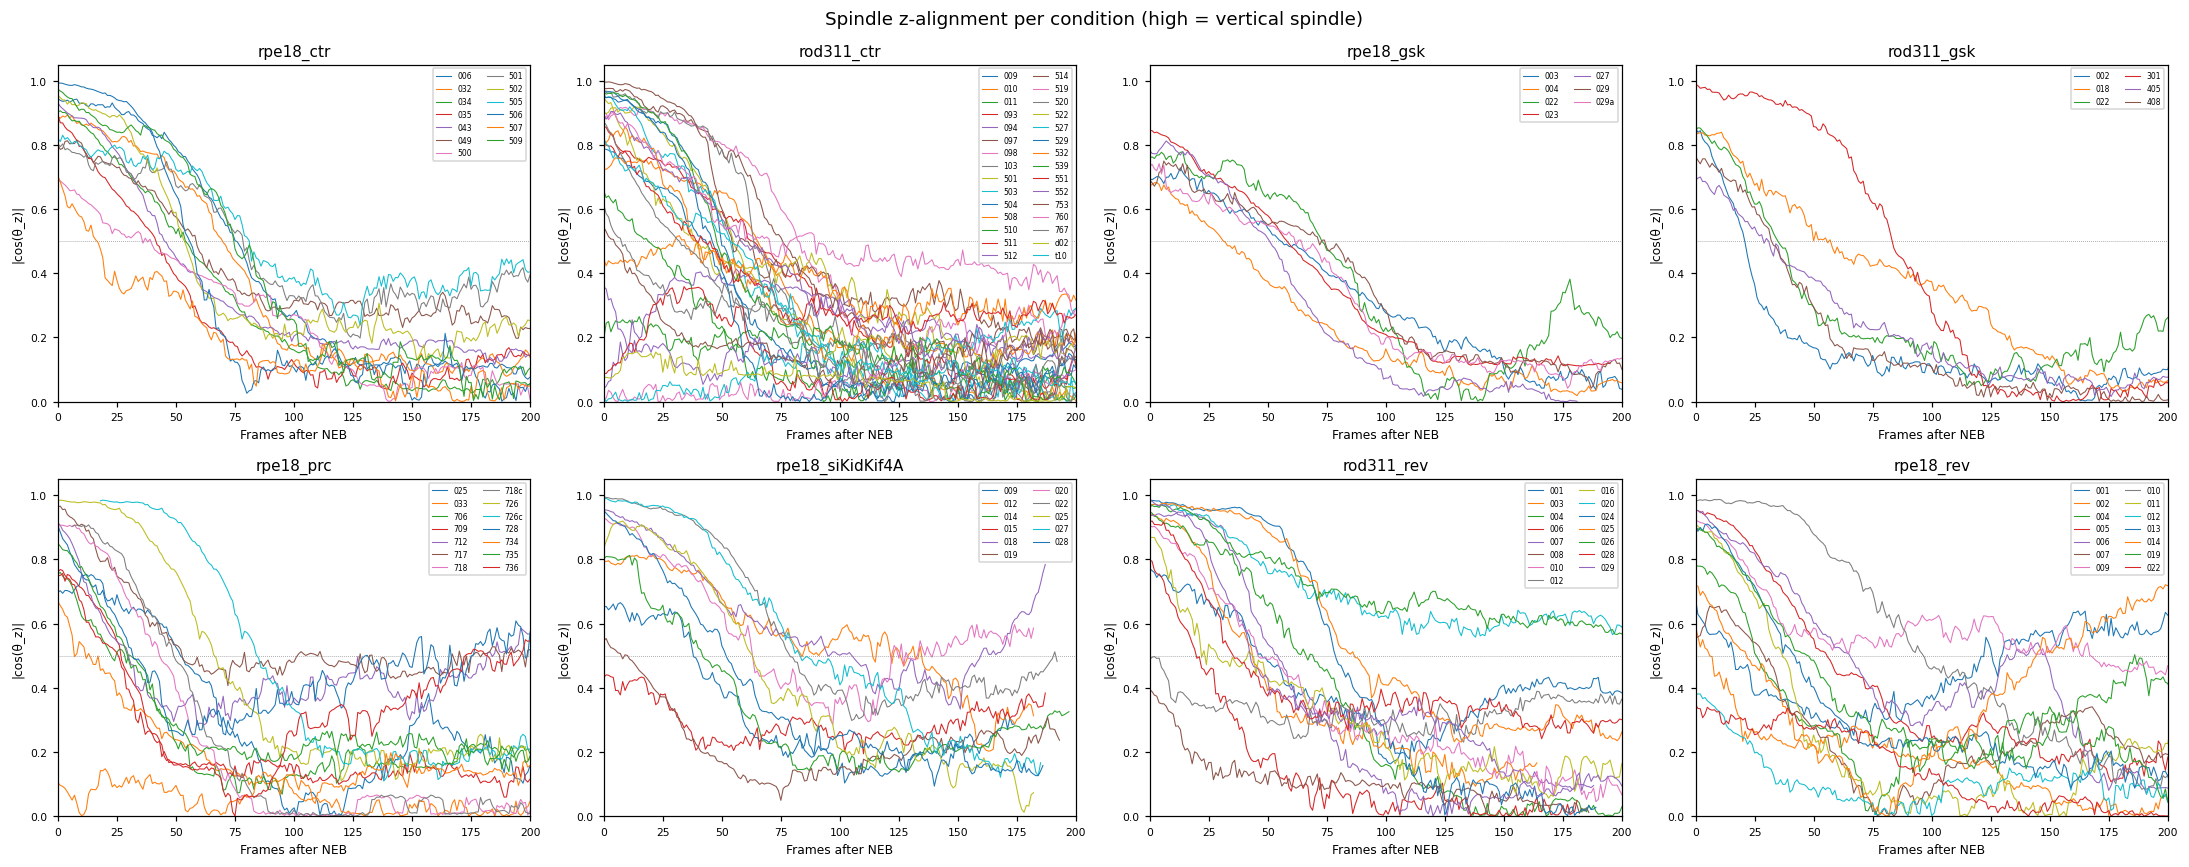

In [8]:
cond_names = [c for c in CONDITIONS if load_condition(c)]  # skip empty conditions
ncond = len(cond_names)
ncols_z = (ncond + 1) // 2
fig, axes = plt.subplots(2, ncols_z, figsize=(5 * ncols_z, 8), squeeze=False)

for ci, cond in enumerate(cond_names):
    ax = axes[ci // ncols_z, ci % ncols_z]
    cells = load_condition(cond)
    for c in cells:
        pole1 = c.centrioles[:, :, 0]
        pole2 = c.centrioles[:, :, 1]
        axis_vec = pole1 - pole2
        cos_z = np.abs(axis_vec[:, 2]) / np.linalg.norm(axis_vec, axis=1)

        neb_idx = c.neb - 1
        vals = cos_z[neb_idx:]
        ax.plot(vals, linewidth=0.7, label=c.cell_id.split("_")[-1])

    ax.set_title(cond, fontsize=10)
    ax.set_xlabel("Frames after NEB", fontsize=8)
    ax.set_ylabel("|cos(θ_z)|", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 200)
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.5)
    ax.legend(fontsize=5, ncol=2, loc="upper right")
    ax.tick_params(labelsize=7)

for idx in range(ncond, 2 * ncols_z):
    axes[idx // ncols_z, idx % ncols_z].set_visible(False)

fig.suptitle("Spindle z-alignment per condition (high = vertical spindle)")
fig.tight_layout()
plt.show()

## Spindle elongation grid — all cells

Pole-pole distance over time with NEB, AO, end_sep, and midpoint(NEB,AO)
markers. Cells with a short training window are marked with `*`.

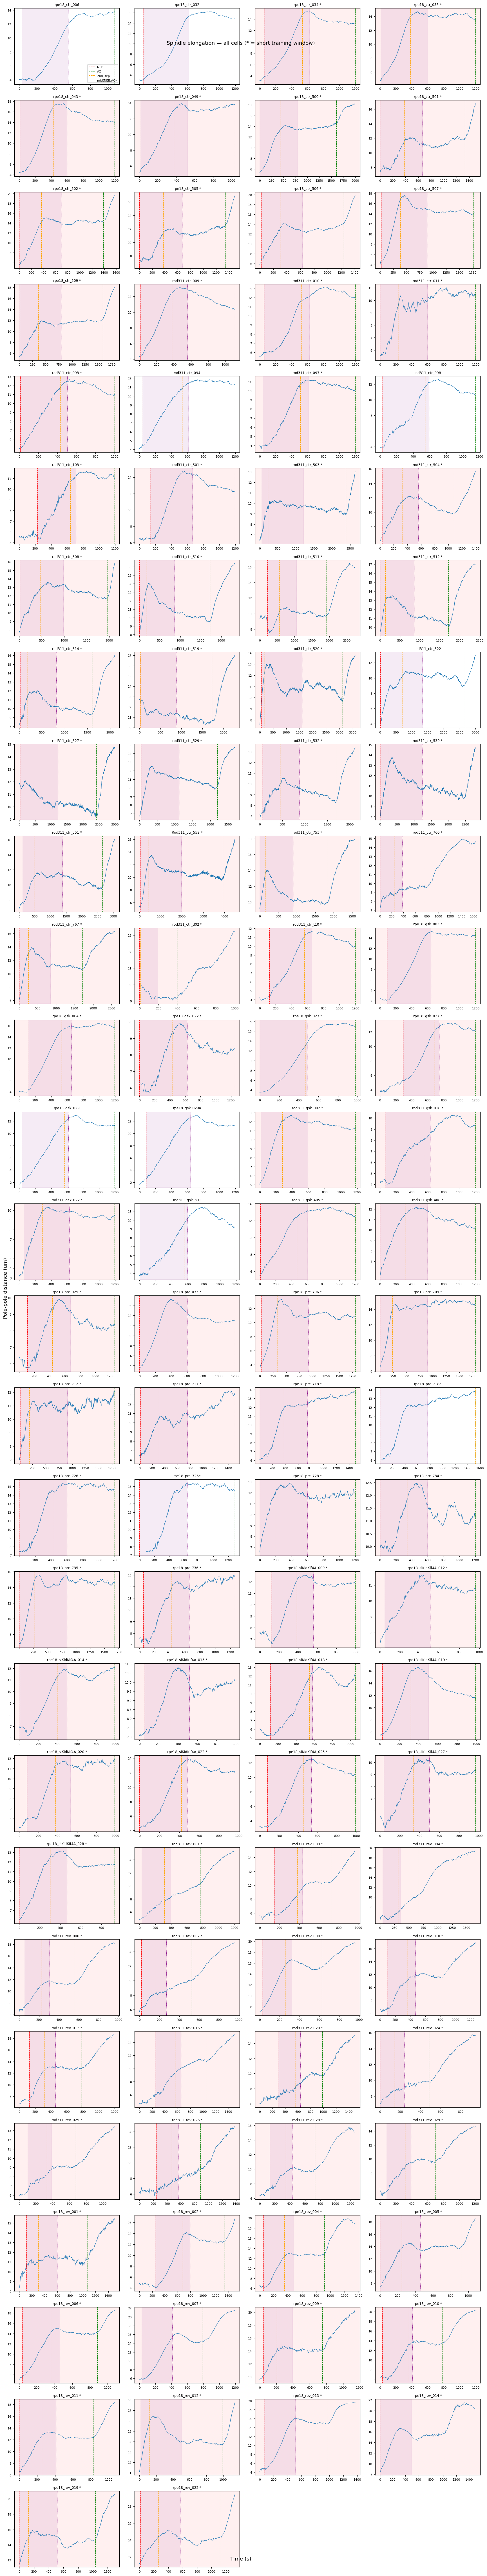

In [9]:
n = len(all_cells)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)

for idx, c in enumerate(all_cells):
    ax = axes[idx // ncols, idx % ncols]
    ppd = pole_pole_distance(c)
    t = np.arange(len(ppd)) * c.dt

    neb_frame = c.neb - 1
    ao_mean_frame = int(round((c.ao1 + c.ao2) / 2.0)) - 1
    midpoint_frame = (neb_frame + ao_mean_frame) // 2
    end_sep_frame = compute_end_sep(c)

    ax.plot(t, ppd, linewidth=0.8)
    ax.axvline(neb_frame * c.dt, color="r", linestyle="--", linewidth=0.8, label="NEB")
    ax.axvline(ao_mean_frame * c.dt, color="g", linestyle="--", linewidth=0.8, label="AO")
    ax.axvline(end_sep_frame * c.dt, color="orange", linestyle="--", linewidth=0.8, label="end_sep")
    ax.axvline(midpoint_frame * c.dt, color="purple", linestyle=":", linewidth=0.8, label="mid(NEB,AO)")

    # Shade the default training window
    ax.axvspan(neb_frame * c.dt, midpoint_frame * c.dt, alpha=0.08, color="purple")

    title = c.cell_id
    if window_info[c.cell_id]["short"]:
        title += " *"
        ax.set_facecolor("#fff0f0")
    ax.set_title(title, fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7, loc="lower right")

for idx in range(n, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.supxlabel("Time (s)")
fig.supylabel("Pole-pole distance (um)")
fig.suptitle("Spindle elongation — all cells (* = short training window)")
fig.tight_layout()
plt.show()